# Template for CS5004 Task 3 --> Loading the Atari ROM
Using gym for this task as Gymnasium requires you to dowload the ROMs

Acknowledgement: Anuja Katkar, https://github.com/AnujaKatkar/OpenAI-Gym-Breakout-Env/blob/main/Notebooks/DQN_Breakout.ipynb

11 March 2025

In [1]:
import sys
assert sys.version_info >= (3, 7)

In [2]:
#install gym and Arcade Learning Environment (ALE)
!pip install ale_py
!pip install gym[atari,accept-rom-license]

In [3]:
# Imports
import gym
import numpy as np
import random
from collections import deque
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
import cv2
import tensorflow as tf

In [4]:
# Import Keras
IS_COLAB = "google.colab" in sys.modules
if IS_COLAB:
    os.environ["TF_USE_LEGACY_KERAS"] = "1"
    import tf_keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

In [5]:
# Breakout environment using the ALE/Breakout-v5 configuration from openAi gym
# render mode in rgb array to capture frames in rgb mode for visualisation
env = gym.make('ALE/Breakout-v5', render_mode='rgb_array')

# The ALE namespace doesn't have max steps set for Breakout, so we explicty set it to 27,000 steps, default for atari.
env.spec.max_episode_steps = 27000

# Print out some environment details
print(gym.envs.registry.keys())  # Overview over the flavors of environments that can be accessed through gym

print("Action Space:", env.action_space)
print("Observation Space:", env.observation_space)
print("Max Steps:", env.spec.max_episode_steps)
print("Reward Range:", env.reward_range)

# Set the state and action size
# state_size is the dimensions of the game's screen
# action_size is thee number actions available to the agent (Breakout offers [NOOP, FIRE, LEFT, RIGHT]
state_size = env.observation_space.shape
action_size = env.action_space.n

dict_keys(['ALE/Adventure-v5', 'ALE/Adventure-ram-v5', 'ALE/AirRaid-v5', 'ALE/AirRaid-ram-v5', 'ALE/Alien-v5', 'ALE/Alien-ram-v5', 'ALE/Amidar-v5', 'ALE/Amidar-ram-v5', 'ALE/Assault-v5', 'ALE/Assault-ram-v5', 'ALE/Asterix-v5', 'ALE/Asterix-ram-v5', 'ALE/Asteroids-v5', 'ALE/Asteroids-ram-v5', 'ALE/Atlantis-v5', 'ALE/Atlantis-ram-v5', 'ALE/Atlantis2-v5', 'ALE/Atlantis2-ram-v5', 'ALE/Backgammon-v5', 'ALE/Backgammon-ram-v5', 'ALE/BankHeist-v5', 'ALE/BankHeist-ram-v5', 'ALE/BasicMath-v5', 'ALE/BasicMath-ram-v5', 'ALE/BattleZone-v5', 'ALE/BattleZone-ram-v5', 'ALE/BeamRider-v5', 'ALE/BeamRider-ram-v5', 'ALE/Berzerk-v5', 'ALE/Berzerk-ram-v5', 'ALE/Blackjack-v5', 'ALE/Blackjack-ram-v5', 'ALE/Bowling-v5', 'ALE/Bowling-ram-v5', 'ALE/Boxing-v5', 'ALE/Boxing-ram-v5', 'ALE/Breakout-v5', 'ALE/Breakout-ram-v5', 'ALE/Carnival-v5', 'ALE/Carnival-ram-v5', 'ALE/Casino-v5', 'ALE/Casino-ram-v5', 'ALE/Centipede-v5', 'ALE/Centipede-ram-v5', 'ALE/ChopperCommand-v5', 'ALE/ChopperCommand-ram-v5', 'ALE/CrazyClimb

In [6]:
def display_frame(state):
    """
    Metod to Visualise state of the Breakout environment from OpenAi Gym
    """
    #state = env.reset()  # Reset the environment to inital state
    if isinstance(state, tuple):
        state = state[0]
    # Plot state
    plt.imshow(state)
    plt.title("State of Breakout Environment")
    plt.axis('off')
    plt.show()

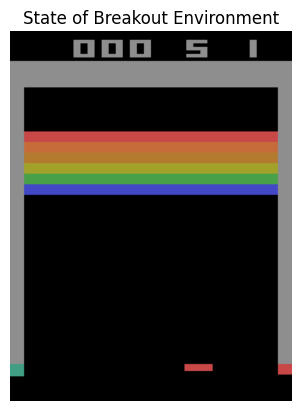

In [7]:
display_frame(env.reset())

/usr/local/lib/python3.11/dist-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


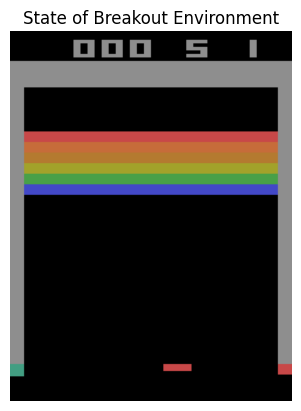

In [8]:
next_state, reward, done, _, _ = env.step(3)
display_frame(next_state)

In [9]:
def preprocess1(im):
      temp = im[50:-12,6:-6]
      temp = tf.image.rgb_to_grayscale(temp)
      temp = tf.image.resize(temp, [110, 84], method = tf.image.ResizeMethod.NEAREST_NEIGHBOR)
      temp = tf.cast(temp, tf.float32)
      return temp[:,:,0] / 255.0

In [10]:
def preprocess2(im):
    im = im[31:195,:,:]  # Crop the height interval to [31:195], leaving the width unchanged
    im = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY) # Convert to grayscale image
    im = cv2.resize(im, (84, 84), interpolation=cv2.INTER_AREA) # Zoom to (84, 84)
    return im / 255.0  # Standardize to [0, 1]

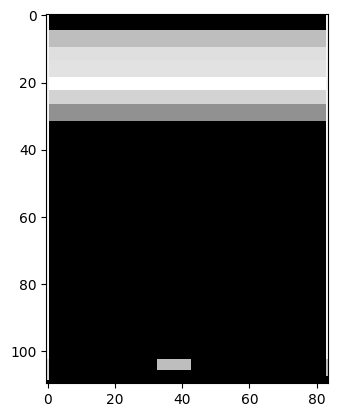

In [11]:
next_state, reward, done, _, _ = env.step(3)
processed_state = preprocess1(next_state)
#display_frame(processed_state)
plt.imshow(processed_state,cmap = 'gray')
plt.show()

In [12]:
def combine(im1, im2):
      if len(im1.shape) == 3 and im1.shape[0] == 4:  # checks if im1 already is a stack -->has 4 elements in the last dimension) that im2 can be appended to; dimesnions (batchsize = 1, height, width, stack size = 4) and im2 should be a single frame
        im2 = np.expand_dims(im2, 0)  # expand single frame im2 so that there is a batch size dimension
        im2 = np.expand_dims(im2, 3)  # expand single frame im2 so that there is a frame stack dimension -> necessary for appending
        im = np.append(im1[:,:,:,1:], im2, axis = 3) # im1[:, :, :, 1:] selects the three newest frames in the stack and appends im2 to it as the fourth
        return im
      else:  # if the first parameter is a single frame (which is the case for the first frame ever passed), this copies this single frame to produce a frame stack -> we don't want this to happen if we got beyond the first frame, so that temporal information are actually contained in the frame stack
        im = np.stack([im1]*4, axis = 2)  # appends 4 copies of im1 together
        return tf.expand_dims(im, 0)  # adds batch size dimension


In [13]:
def act(state):
  #if np.random.rand() <= self.epsilon:
    return np.random.randint(action_size)
  #q_values = self.model.predict(state, verbose = 0)
  #return np.argmax(q_values[0])

(1, 110, 84, 4)


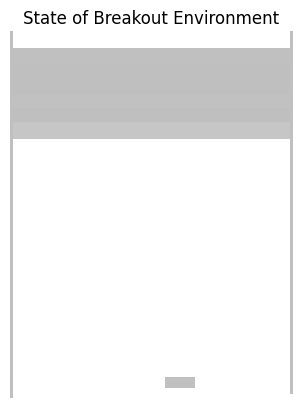

In [14]:
# example of using preprocess and combine to create stacked frames
# moce this into the training loop
# store stacked frames in replay buffer
# sample stacked frames from replay buffer
state, info = env.reset()
state = preprocess1(state)
action = act(state)
nextState, reward, done, _, _ = env.step(action)
nextState= preprocess2(nextState)
nextState = combine(nextState, state)

action = act(nextState)
state = nextState
nextState, reward, done, _, _ = env.step(action)
nextState= preprocess1(nextState)
nextState = combine(nextState, state)

print(nextState.get_shape())
display_frame(nextState[-0])


In [15]:
print(state_size)

(210, 160, 3)


In [16]:
def build_model():
  model = Sequential()
  model.add(Conv2D(32, 8, (4,4), activation = 'relu', padding = 'valid', input_shape = state_size)) # TODO: maybe use elu
  model.add(Conv2D(64, 4, (2,2), activation = 'relu', padding = 'valid'))
  model.add(MaxPooling2D())
  model.add(Conv2D(64, 3, (1,1), activation = 'relu', padding = 'valid'))
  model.add(MaxPooling2D())
  model.add(Flatten())
  model.add(Dense(256, activation='relu'))
  model.add(Dense(action_size, activation='linear'))
  model.compile(optimizer=Adam(), loss=MeanSquaredError())
  model.summary()
  return model

In [17]:
model = build_model()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 51, 39, 32)          │           6,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 24, 18, 64)          │          32,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 12, 9, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 10, 7, 64)           │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 3, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 960)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         246,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 322,980 (1.23 MB)

 Trainable params: 322,980 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on the CPU upon each rerun
n_outputs = env.action_space.n  # Number of available actions

def epsilon_greedy_policy(state, epsilon=0):
    if np.random.rand() < epsilon:
        return np.random.randint(n_outputs)  # random action epsilon percent of the time
    else:
        Q_values = model.predict(state[np.newaxis], verbose=0)[0]
        return Q_values.argmax()  # optimal action according to the DQN


In [19]:
#  Create the Target Model (Copy of Main Model)
target_model = tf.keras.models.clone_model(model)
target_model.set_weights(model.get_weights())  # Copy initial weights


In [20]:
# extra code – A basic circular buffer implementation

from collections import deque

replay_buffer = deque(maxlen=2000)

def sample_experiences(batch_size):
    indices = np.random.randint(len(replay_buffer), size=batch_size)
    batch = [replay_buffer[index] for index in indices]
    return [
        np.array([experience[field_index] for experience in batch])
          for field_index in range(6)
    ]  # [states, actions, rewards, next_states, dones, truncateds]

In [26]:
def sample_experiences(batch_size):
    batch = random.sample(replay_buffer, batch_size)

    # Extract the first 5 elements only (ignore `truncated`)
    states, actions, rewards, next_states, dones, _ = zip(*batch)

    return (
        np.array(states, dtype=np.float32),
        np.array(actions, dtype=np.int32),
        np.array(rewards, dtype=np.float32),
        np.array(next_states, dtype=np.float32),
        np.array(dones, dtype=np.float32),
    )


In [21]:
# extra code – for reproducibility, and to generate the next figure
env.reset(seed=42)
np.random.seed(42)
tf.random.set_seed(42)
rewards = []
best_score = 0

In [22]:
batch_size = 64
discount_factor = 0.95
optimizer = tf.keras.optimizers.Nadam(learning_rate=5e-4)
loss_fn = tf.keras.losses.MeanSquaredError()

def training_step(batch_size):
    experiences = sample_experiences(batch_size)
    states, actions, rewards, next_states, dones, truncateds = experiences
    #next_Q_values = model.predict(next_states, verbose=0)
    next_Q_values = target_model.predict(next_states, verbose=0)
    max_next_Q_values = next_Q_values.max(axis=1)
    runs = 1.0 - (dones | truncateds)  # episode is not done or truncated
    runs = 1.0 - dones  # No need for truncateds
    target_Q_values = rewards + runs * discount_factor * max_next_Q_values
    target_Q_values = target_Q_values.reshape(-1, 1)
    mask = tf.one_hot(actions, n_outputs)
    with tf.GradientTape() as tape:
        all_Q_values = model(states)
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1, keepdims=True)
        loss = tf.reduce_mean(loss_fn(target_Q_values, Q_values))

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

In [23]:
def play_one_step(env, state, epsilon):
    action = epsilon_greedy_policy(state, epsilon)
    next_state, reward, done, truncated, info = env.step(action)
    replay_buffer.append((state, action, reward, next_state, done, truncated))
    return next_state, reward, done, truncated, info

In [24]:
def training_step(batch_size):
    # Sample experiences from replay buffer
    experiences = sample_experiences(batch_size)
    states, actions, rewards, next_states, dones = experiences  # Truncated not needed

    # Convert data to TensorFlow tensors
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    next_states = tf.convert_to_tensor(next_states, dtype=tf.float32)
    actions = tf.convert_to_tensor(actions, dtype=tf.int32)
    rewards = tf.convert_to_tensor(rewards, dtype=tf.float32)
    dones = tf.convert_to_tensor(dones, dtype=tf.float32)

    # Compute target Q-values using the target network
    next_Q_values = target_model.predict(next_states, verbose=0)
    max_next_Q_values = tf.reduce_max(next_Q_values, axis=1)

    runs = 1.0 - tf.cast(dones, dtype=tf.float32)  # No need for truncateds

    # Bellman equation: Q_target = R + γ * max(Q_next)
    target_Q_values = rewards + runs * discount_factor * max_next_Q_values

    target_Q_values = tf.reshape(target_Q_values, (-1, 1))

    # Compute mask for actions
    mask = tf.one_hot(actions, depth=n_outputs, dtype=tf.float32)

    # Compute loss and update model weights using SGD
    with tf.GradientTape() as tape:
        all_Q_values = model(states)
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1, keepdims=True)
        loss = tf.reduce_mean(loss_fn(target_Q_values, Q_values))

    grads = tape.gradient(loss, model.trainable_variables)

    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    return loss.numpy()


In [28]:
q_values_log = []

for episode in range(1000):
    obs, info = env.reset()
    total_reward=0
    epsilon = 0.01 + (1.0 - 0.01) * np.exp(-episode / 600)
    epsilon = max(0.01, 1.0 - episode / 1000)
    # epsilon = 0.9
    for step in range(4000):
        obs, reward, done, truncated, info = play_one_step(env, obs, epsilon)
        total_reward += reward  # Accumulate episode rewards
        if done or truncated:
            break
    # Store Q-values for analysis
    q_values = model.predict(obs[np.newaxis], verbose=0)[0]  # Get Q-values for current state
    q_values_log.append(q_values)

    # extra code – displays debug info, stores data for the next figure, and
    #              keeps track of the best model weights so far
    print(f"\rEpisode: {episode + 1}, Steps: {step + 1}, Reward: {total_reward}, eps: {epsilon:.3f}",
          end="")
    rewards.append(step)
    rewards.append(total_reward)
    if total_reward >= best_score:
        best_weights = model.get_weights()
        best_score = total_reward
        print(f"\n New High Score: {best_score:.2f}")

    if episode > 100:
        training_step(batch_size)

    # if len(replay_buffer) > batch_size * 10:  # Ensure buffer has enough samples
    #       training_step(batch_size)

    # Update Target Network every 5 episodes
    if episode % 50 == 0:
        target_model.set_weights(model.get_weights())

model.set_weights(best_weights)  # extra code – restores the best model weights

Episode: 5, Steps: 356, Reward: 5.0, eps: 0.996
 New High Score: 5.00
Episode: 50, Steps: 304, Reward: 5.0, eps: 0.951
 New High Score: 5.00
Episode: 60, Steps: 301, Reward: 5.0, eps: 0.941
 New High Score: 5.00
Episode: 250, Steps: 292, Reward: 7.0, eps: 0.751
 New High Score: 7.00
Episode: 261, Steps: 512, Reward: 8.0, eps: 0.740
 New High Score: 8.00
Episode: 308, Steps: 446, Reward: 11.0, eps: 0.693
 New High Score: 11.00
Episode: 586, Steps: 123, Reward: 0.0, eps: 0.415

KeyboardInterrupt: 

NameError: name 'save_fig' is not defined

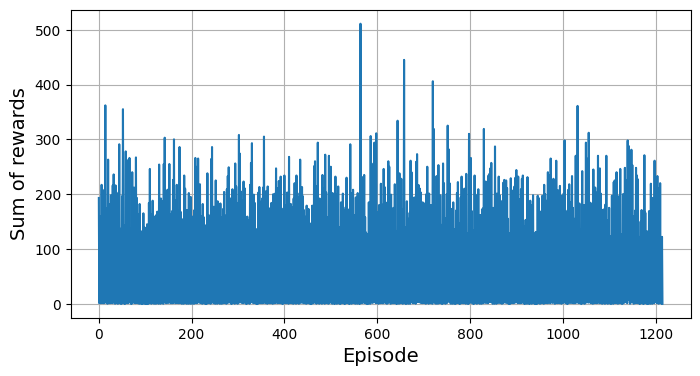

In [29]:
# extra code – this cell generates and saves Figure 18–10
plt.figure(figsize=(8, 4))
plt.plot(rewards)
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.grid(True)
save_fig("dqn_ll_rewards_plot")
plt.show()

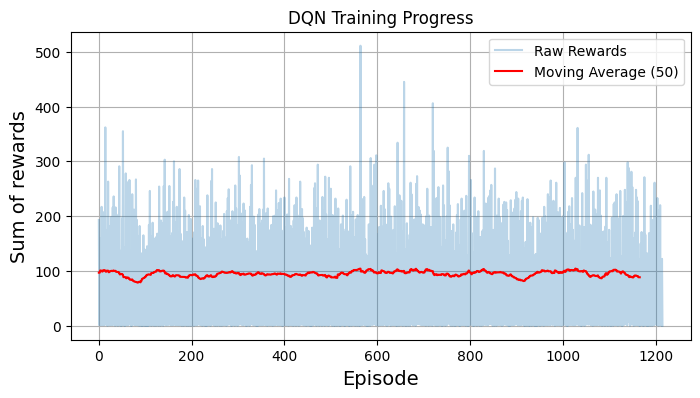

In [30]:
# Define moving average function
def moving_average(values, window_size=50):
    return np.convolve(values, np.ones(window_size)/window_size, mode='valid')

# Generate reward plot with moving average
plt.figure(figsize=(8, 4))
plt.plot(rewards, label="Raw Rewards", alpha=0.3)  # Original noisy rewards
plt.plot(moving_average(rewards, window_size=50), label="Moving Average (50)", color="red")
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.legend()
plt.grid(True)
plt.title("DQN Training Progress")

# Show plot
plt.show()

No strong increase

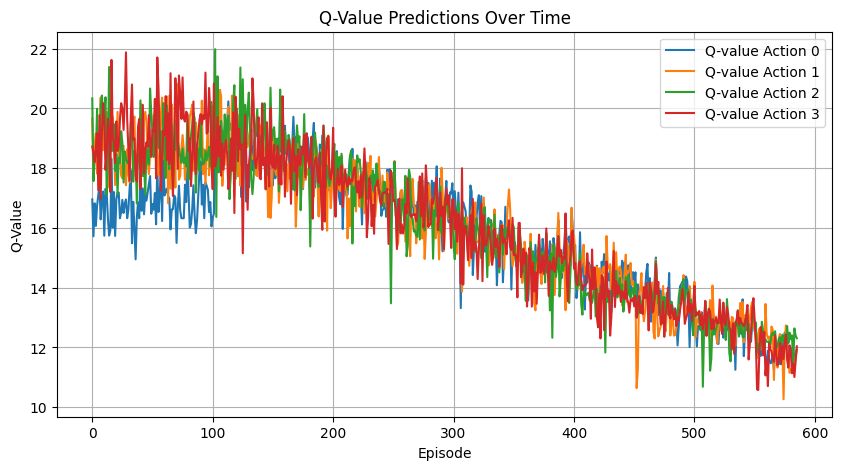

In [31]:
# Convert Q-values to NumPy array for plotting
q_values_log = np.array(q_values_log)

plt.figure(figsize=(10, 5))

# Plot Q-values for each action over episodes
for action in range(n_outputs):
    plt.plot(q_values_log[:, action], label=f"Q-value Action {action}")

plt.xlabel("Episode")
plt.ylabel("Q-Value")
plt.title("Q-Value Predictions Over Time")
plt.legend()
plt.grid()
plt.show()

Define training

Training step

Testing

Running

### Improvements that could be made

#### Double DQN

#### Fixed DQN

#### Sampling different parts of game state


## Reflect